# Hamiltonian Identification — Hydrogen Atom (3D)

Experiment (Theorem 4.1 applied). We sample from the exact hydrogen ground state $\rho_0 \propto |\psi_{1s}|^2 = e^{-2r}/\pi$, train a score network $S_\theta \approx \nabla\log\rho_0$, and recover the underlying Coulomb potential directly via the score-based expansion of the Quantum potential:
$$\hat{V}(r) = -Q_\theta(r), \qquad Q_\theta = -\tfrac{1}{4}\nabla\cdot S_\theta - \tfrac{1}{8}|S_\theta|^2,$$
yielding the Score Hamiltonian $\hat{H}^{\theta}$ which -- by Theorem 4.1 -- can exactly recover $\hat{H}$ up to $E_{0}$ through score-matching on density samples
$$\hat{H}^{\theta} = - \frac{1}{2}\nabla^2 + \tfrac{1}{4}\nabla\cdot S_\theta + \tfrac{1}{8}|S_\theta|^2 $$
Result: The learned $\hat{V}(r)$ recovers not only the ground state but also excited-state energies $E_n = -1/(2n^2)$ and orbital shapes -- from 1s training data only. Theoretically, this principle is viable due to the Hohenberg-Kohn theorem (Hohenberg & Kohn '64) of density functional theory which states that the potential $\hat{V}$ of a quantum system is uniquely determined by the ground-state density $|\psi_{0}|^{2}$ (in other words, that $|\psi_{0}|^{2}$ is a non-compressive representation of $\hat{V}$).

Architecture: `QuantumStateNet` uses Gaussian Fourier projections for the noise level embedding. The score itself is shared between the Score-Hamiltonian and the Hamiltonian computed from the standard thermodynamic interpretation of the diffusion model's score applied in Machine-Learning for physics to highlight that the distinction of the Score Hamiltonian is not in how the score is specifically trained, but how it is ontologically treated for computing a Quantum Hamiltonian. 

A cusp inductive bias is shared by all of the networks. The Boltzmann-Generator is trained with a separate architecture, as it is normalizing-flow rather than score based and thus model $\rho_{\theta}$ directly via the change of variables formula
$$
\log \rho_{\theta}(x) = \log \rho_{0}(f(x)) + \log \left|  \det \mathbf{J}_f x \right|
$$
Supposing an invertible transformation $f$ directly mapping a reference $\rho_{0}$ (e.g., Gaussian) to a model of the target $\rho_{\theta}(x)$. For the generator, we explicitly enforce the a priori known Coloumb score in training in addition to the negative log-likelihood loss on samples. The score-based correction MLP used for the Score Hamiltonian and the thermodynamic potential is parametrized by a conservative score via a potential $-\log \rho_{\theta} = \phi: \mathbb{R}^{3} \to \mathbb{R}$ for which $\nabla \log \rho_{\theta} = S^{\theta} = - \nabla \phi$. We additionally offer the score-based models a cusp bias with an effective nuclear charge Z_eff *initialized away* from its physical value so that both the radial corrections and cusp slope must be learned during training. This notebook is an adaptation of the experiment in the paper and precise details for reproducting it are offered in Appendix D.1.



In [3]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import interp1d

try:
    import nflows
    HAS_NFLOWS = True
except ImportError:
    HAS_NFLOWS = False

from src.density_sampler import sample_hydrogen_ground_state
from src.models import GaussianFourierProjection, QuantumStateNet, NetWrapper
from src.training import train_dqm, build_nf_flow, train_nf
from src.hamiltonian import solve_schrodinger_1d

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
L_BOX      = 60.0   # radial box (Bohr)
R_GRID_PTS = 2000   # Schrödinger solver resolution
torch.manual_seed(42); np.random.seed(42)
print(f"Device: {DEVICE}")
print(f"nflows available: {HAS_NFLOWS}")

# Custom colormap used for orbital plots
cdict = {
    'red':   ((0.0, 0.0, 0.0), (0.5, 0.0, 0.0), (1.0, 1.0, 1.0)),
    'green': ((0.0, 0.0, 0.0), (0.0, 0.0, 0.0), (1.0, 1.0, 1.0)),
    'blue':  ((0.0, 0.0, 0.0), (0.5, 1.0, 1.0), (1.0, 1.0, 1.0)),
}
electric_cmap = LinearSegmentedColormap('Electric', cdict)

# ── Execute ───────────────────────────────────────────────────────────────────
print("Sampling 1s ground-state data...")
data = sample_hydrogen_ground_state(20000)

dqm = train_dqm(data, DEVICE, epochs=2000)

Device: cuda
nflows available: True
Sampling 1s ground-state data...


Training score model:   2%|▏         | 32/2000 [00:00<00:06, 314.56it/s]

  step    0  loss 3.0256  Z_eff 1.104


Training score model:  28%|██▊       | 550/2000 [00:01<00:04, 313.77it/s]

  step  500  loss 2.9006  Z_eff 0.932


Training score model:  53%|█████▎    | 1062/2000 [00:03<00:02, 313.87it/s]

  step 1000  loss 2.9128  Z_eff 0.942


Training score model:  77%|███████▋  | 1542/2000 [00:04<00:01, 313.71it/s]

  step 1500  loss 2.8844  Z_eff 0.939


Training score model: 100%|██████████| 2000/2000 [00:06<00:00, 315.18it/s]


In [4]:
flow_model = train_nf(data, DEVICE, epochs=2000)

Training normalizing flow:   0%|          | 4/2000 [00:00<00:59, 33.65it/s]

  step    0  NLL 4.8776  cusp 1.2058


Training normalizing flow:  15%|█▌        | 304/2000 [00:08<00:49, 33.99it/s]

  step  300  NLL 4.2324  cusp 0.5387


Training normalizing flow:  30%|███       | 604/2000 [00:17<00:41, 34.04it/s]

...

Training normalizing flow:  75%|███████▌  | 1504/2000 [00:44<00:14, 34.01it/s]

  step 1500  NLL 4.1776  cusp 0.5480


Training normalizing flow:  90%|█████████ | 1804/2000 [00:52<00:05, 33.83it/s]

  step 1800  NLL 4.2386  cusp 0.4710


Training normalizing flow: 100%|██████████| 2000/2000 [00:58<00:00, 34.07it/s]



Gauge-root diagnostics:
Score Hamiltonian        raw 1s: -0.4807 | gauge shift: -0.0193
Thermodynamic integral   raw 1s: -104.9522 | gauge shift: +104.4522
Normalizing flow -logρ   raw 1s: -40.7591 | gauge shift: +40.2591

Saved metrics table to: hydrogen_spectrum_metrics.csv
state  n  l  exact_E  score_h_E  thermo_E  flow_E  abs_err_score_h  abs_err_thermo  abs_err_flow flow_status thermo_status
   1s  1  0  -0.5000    -0.5000   -0.5000 -0.5000          +0.0000         +0.0000       +0.0000       bound         bound
   2s  2  0  -0.1250    -0.1266   unbound unbound          +0.0016         unbound       unbound     unbound       unbound
   2p  2  1  -0.1250    -0.1219   unbound unbound          +0.0031         unbound       unbound     unbound       unbound
   3s  3  0  -0.0556    -0.0572   unbound unbound          +0.0016         unbound       unbound     unbound       unbound
   3p  3  1  -0.0556    -0.0559   unbound unbound          +0.0004         unbound       unbound     unboun

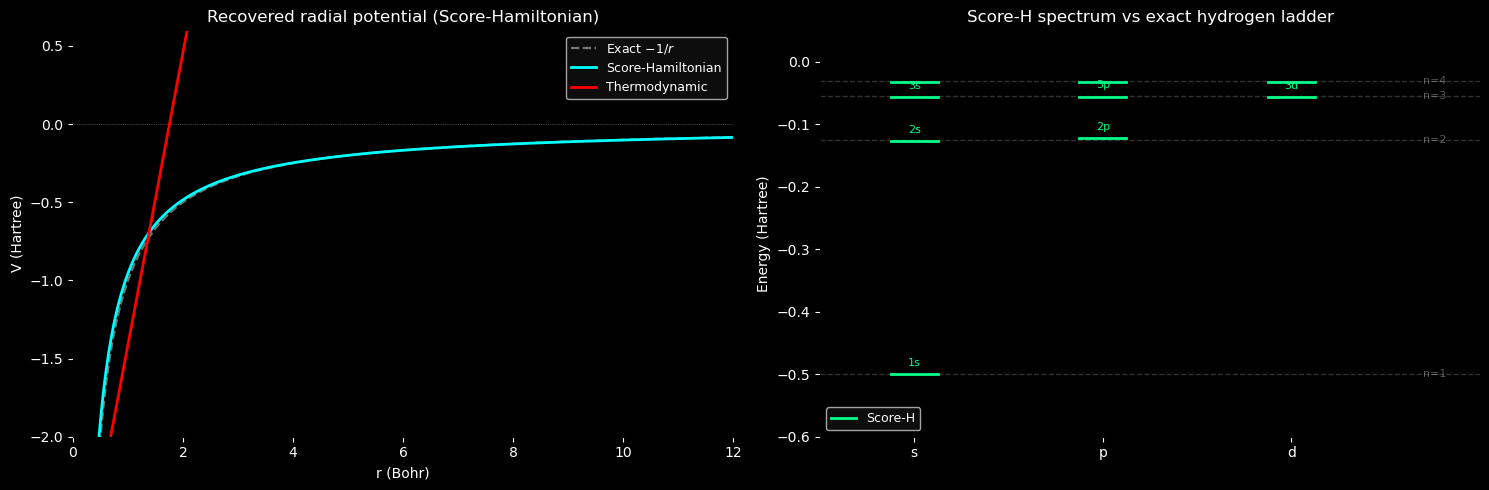

In [5]:
from src.hamiltonian import (
    spectrum_from_potential,
    extract_score_hamiltonian_potential_radial,
    extract_thermodynamic_potential,
    extract_flow_potential,
)
from src.utils import get_energy, fmt_energy, fmt_error

r_grid = np.linspace(0.01, L_BOX, R_GRID_PTS)

V_score_raw = extract_score_hamiltonian_potential_radial(dqm, DEVICE, r_grid)
V_thermo_raw = extract_thermodynamic_potential(dqm, DEVICE, r_grid)
V_flow_raw = extract_flow_potential(flow_model, DEVICE, r_grid)

print("\nGauge-root diagnostics:")
V_score, states_score = spectrum_from_potential(r_grid, V_score_raw, "Score Hamiltonian")
V_thermo, states_thermo = spectrum_from_potential(r_grid, V_thermo_raw, "Thermodynamic integral")

if V_flow_raw is not None:
    V_flow, states_flow = spectrum_from_potential(r_grid, V_flow_raw, "Normalizing flow -logρ")
else:
    V_flow, states_flow = None, {}

# Keep score-Hamiltonian states for orbital plotting in the next cell
states = states_score
V_learned = V_score

# ── Metrics table (exported) ──────────────────────────────────────────────────
target_states = [(1, 0), (2, 0), (2, 1), (3, 0), (3, 1), (3, 2)]
rows = []
for n, l in target_states:
    exact = -0.5 / n**2
    e_sc = get_energy(states_score, (n, l))
    e_th = get_energy(states_thermo, (n, l))
    e_fl = get_energy(states_flow, (n, l))

    d_sc = np.nan if np.isnan(e_sc) else abs(e_sc - exact)
    d_th = np.nan if np.isnan(e_th) else abs(e_th - exact)
    d_fl = np.nan if np.isnan(e_fl) else abs(e_fl - exact)

    rows.append(
        {
            "state": f"{n}{'spd'[l]}",
            "n": n,
            "l": l,
            "exact_E": exact,
            "score_h_E": e_sc,
            "thermo_E": e_th,
            "flow_E": e_fl,
            "abs_err_score_h": d_sc,
            "abs_err_thermo": d_th,
            "abs_err_flow": d_fl,
            "flow_status": "unbound" if np.isnan(e_fl) else "bound",
            "thermo_status": "unbound" if np.isnan(e_th) else "bound",
        }
    )

metrics_df = pd.DataFrame(rows)
metrics_path = "hydrogen_spectrum_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print(f"\nSaved metrics table to: {metrics_path}")
print(metrics_df.to_string(index=False, na_rep="unbound", float_format=lambda v: f"{v:+.4f}"))

# ── Visualisation (only Score-H vs exact) ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), facecolor='black')
mask = r_grid > 0.3

# Left: potential comparison (score only)
ax1.set_facecolor('black')
ax1.plot(r_grid[mask], -1.0 / r_grid[mask], 'w--', alpha=0.45, lw=1.6, label='Exact $-1/r$')
ax1.plot(r_grid[mask], V_score[mask], color='#00ffff', lw=2.0, label='Score-Hamiltonian')

ax1.plot(r_grid[mask], V_thermo[mask], color='red', lw=2.0, label='Thermodynamic')

ax1.axhline(0, color='gray', lw=0.5, ls=':')
ax1.set_xlim(0, 12); ax1.set_ylim(-2.0, 0.6)
ax1.set_xlabel('r (Bohr)', color='white'); ax1.set_ylabel('V (Hartree)', color='white')
ax1.set_title('Recovered radial potential (Score-Hamiltonian)', color='white')
ax1.legend(facecolor='#111', labelcolor='white', fontsize=9)
ax1.tick_params(colors='white')

# Right: spectral comparison (score only)
ax2.set_facecolor('black')
l_x = {0: 0.2, 1: 1.0, 2: 1.8}
for n in range(1, 5):
    e_exact = -0.5 / n**2
    ax2.axhline(e_exact, color='white', ls='--', alpha=0.2, lw=1.0)
    ax2.text(2.36, e_exact, f"n={n}", color='white', fontsize=8, va='center', alpha=0.35)

for (n, l), s in states_score.items():
    if n > 4:
        continue
    x = l_x[l]
    ax2.plot([x - 0.10, x + 0.10], [s['E'], s['E']], color='#00ff88', lw=2.0)
    if n <= 3:
        ax2.text(x, s['E'] + 0.013, f"{n}{'spd'[l]}", color='#00ff88', ha='center', fontsize=8)

ax2.legend(
    handles=[plt.Line2D([0], [0], color='#00ff88', lw=2, label='Score-H')],
    facecolor='#111',
    labelcolor='white',
    fontsize=9,
    loc='lower left',
)
ax2.set_xlim(-0.2, 2.6); ax2.set_ylim(-0.6, 0.05)
ax2.set_xticks([0.2, 1.0, 1.8]); ax2.set_xticklabels(['s', 'p', 'd'], color='white')
ax2.set_ylabel('Energy (Hartree)', color='white')
ax2.set_title('Score-H spectrum vs exact hydrogen ladder', color='white')
ax2.tick_params(colors='white')

plt.tight_layout(); plt.show()

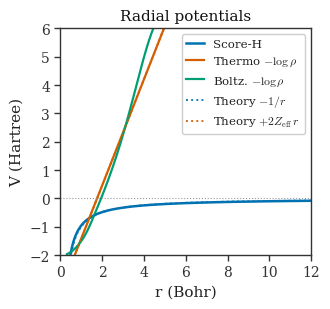

In [6]:
# ── Publication styling ───────────────────────────────────────────────────────
# PRL single column width is ~3.375 to 3.4 inches (8.6 cm).
# We use standard 10pt/11pt sizing without bolding for a clean, professional look.
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.0,           # Standard crisp border
    "axes.edgecolor": "#333333",
    "font.size": 10,                 # Base font size
    "axes.labelsize": 11,            # Slightly larger axis labels
    "axes.titlesize": 11,            # Slightly larger titles
    "xtick.labelsize": 10,           
    "ytick.labelsize": 10,
    "legend.fontsize": 8.5,          # Scaled nicely for the 3.4in width
})

# Colorblind-safe, print-legible on white
C_SCORE  = "#0072B2"   # blue
C_THERMO = "#D55E00"   # vermilion
C_FLOW   = "#009E73"   # green
C_EXACT  = "#000000"   # black (theory references)


# =============================================================================
# Figure 1: Recovered vs analytic radial potentials
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(3.4, 3.2), facecolor="white")

mask = r_grid > 0.3
Z_eff = torch.exp(dqm.log_Z).item()

V_coulomb_pred = -1.0 / r_grid
V_linear_pred  =  2.0 * Z_eff * r_grid

fit = (r_grid > 1.0) & (r_grid < 6.0)
c_coulomb = (V_score[fit]  - V_coulomb_pred[fit]).mean()
c_linear  = (V_thermo[fit] - V_linear_pred[fit]).mean()

# Recovered curves (solid)
ax1.plot(r_grid[mask], V_score[mask],  color=C_SCORE,  lw=1.8, label="Score-H")
ax1.plot(r_grid[mask], V_thermo[mask], color=C_THERMO, lw=1.6, label=r"Thermo $-\log\rho$")
ax1.plot(r_grid[mask], V_flow[mask],   color=C_FLOW,   lw=1.6, label=r"Boltz. $-\log\rho$")

# Analytic overlays (dotted, matched colors)
ax1.plot(r_grid[mask], (V_coulomb_pred + c_coulomb)[mask],
         color=C_SCORE, ls=":", lw=1.4, alpha=0.9, label=r"Theory $-1/r$")
ax1.plot(r_grid[mask], (V_linear_pred + c_linear)[mask],
         color=C_THERMO, ls=":", lw=1.4, alpha=0.9, label=r"Theory $+2Z_{\mathrm{eff}}\,r$")

ax1.axhline(0, color="#999999", lw=0.8, ls=":")
ax1.set_xlim(0, 12)
ax1.set_ylim(-2.0, 6.0)

ax1.set_xlabel("r (Bohr)", color="#222222")
ax1.set_ylabel("V (Hartree)", color="#222222")
ax1.set_title("Radial potentials", color="#111111") 

ax1.legend(facecolor="white", edgecolor="#cccccc", framealpha=0.95,
           labelcolor="#222222", loc="upper right", handlelength=1.5)
ax1.tick_params(colors="#333333", width=1.0, length=4)

fig1.tight_layout()
fig1.savefig("hydrogen_potential.pdf", dpi=600, bbox_inches="tight", facecolor="white")


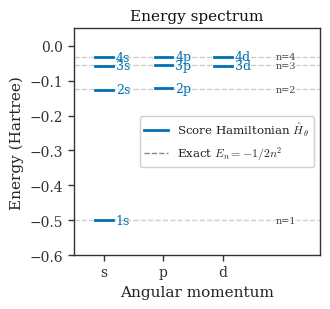

In [7]:
# =============================================================================
# Figure 2: Score-H spectrum vs exact hydrogen ladder
# =============================================================================
fig2, ax2 = plt.subplots(figsize=(3.4, 3.2), facecolor="white")

l_x = {0: 0.2, 1: 1.0, 2: 1.8}
for n in range(1, 5):
    e_exact = -0.5 / n**2
    ax2.axhline(e_exact, color="#888888", ls="--", alpha=0.4, lw=1.0)
    
    # FIX 1: Stagger the x-positions of the reference labels to prevent overlap
    # n=1 and 3 go a bit further right, n=2 and 4 stay a bit more left
    x_pos = 2.5
    # 2.4 if n % 2 == 0 else 2.75
    ax2.text(x_pos, e_exact, f"n={n}", color="#444444", fontsize=7, va="center",
             bbox=dict(facecolor="white", edgecolor="none", pad=1.0, alpha=0.5))

for (n, l), s in states_score.items():
    if n > 4:
        continue
    x = l_x[l]
    ax2.plot([x - 0.12, x + 0.12], [s["E"], s["E"]], color=C_SCORE, lw=2.0)
    
    # FIX 2: Label ALL orbitals up to n=4, and place text horizontally to the RIGHT of the line.
    # We use 'spdf' to safely handle up to l=3 if it exists in your dict.
    if n <= 4:
        ax2.text(x + 0.16, s["E"], f"{n}{'spdf'[l]}", color=C_SCORE, 
                 ha="left", va="center", fontsize=9)

ax2.legend(
    handles=[
        plt.Line2D([0], [0], color=C_SCORE, lw=2.0, label=r"Score Hamiltonian $\hat{H}_{\theta}$"),
        plt.Line2D([0], [0], color="#888888", ls="--", lw=1.0, label="Exact $E_n=-1/2n^2$"),
    ],
    facecolor="white", edgecolor="#cccccc", framealpha=0.95,
    labelcolor="#222222", loc="center right"
)

# Increased the right x-limit to 3.1 to comfortably fit the staggered text
ax2.set_xlim(-0.2, 3.1)
ax2.set_ylim(-0.6, 0.05)
ax2.set_xticks([0.2, 1.0, 1.8])

ax2.set_xticklabels(["s", "p", "d"], color="#222222")
ax2.set_xlabel("Angular momentum", color="#222222")
ax2.set_ylabel("Energy (Hartree)", color="#222222")
ax2.set_title("Energy spectrum", color="#111111")
ax2.tick_params(colors="#333333", width=1.0, length=4)

fig2.tight_layout()
fig2.savefig("hydrogen_spectrum.pdf", dpi=600, bbox_inches="tight", facecolor="white")

plt.show()

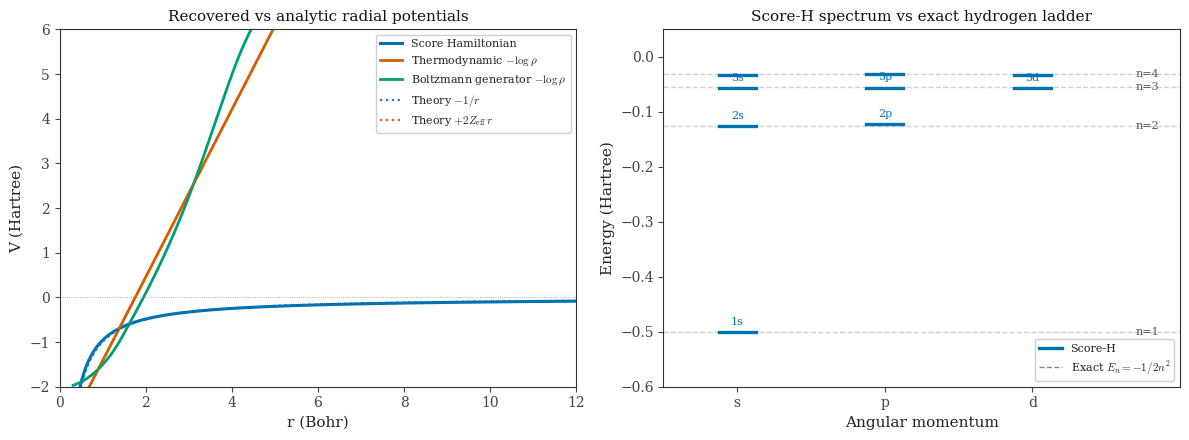

In [8]:
# ── Publication styling ───────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#333333",
})

# Colorblind-safe, print-legible on white
C_SCORE  = "#0072B2"   # blue
C_THERMO = "#D55E00"   # vermilion
C_FLOW   = "#009E73"   # green
C_EXACT  = "#000000"   # black (theory references)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), facecolor="white")

# ── Left: recovered vs analytic potentials ────────────────────────────────────
mask = r_grid > 0.3
Z_eff = torch.exp(dqm.log_Z).item()

V_coulomb_pred = -1.0 / r_grid           # Bohm/Score potential, up to const (½-Lap convention)
V_linear_pred  =  2.0 * Z_eff * r_grid   # -log rho, linear confining well

# Match additive constants to the gauge-rooted recovered curves over a mid window
fit = (r_grid > 1.0) & (r_grid < 6.0)
c_coulomb = (V_score[fit]  - V_coulomb_pred[fit]).mean()
c_linear  = (V_thermo[fit] - V_linear_pred[fit]).mean()

ax1.set_facecolor("white")

# Recovered curves (solid)
ax1.plot(r_grid[mask], V_score[mask],  color=C_SCORE,  lw=2.2, label="Score Hamiltonian")
ax1.plot(r_grid[mask], V_thermo[mask], color=C_THERMO, lw=2.0, label=r"Thermodynamic $-\log\rho$")
ax1.plot(r_grid[mask], V_flow[mask],   color=C_FLOW,   lw=2.0, label=r"Boltzmann generator $-\log\rho$")

# Analytic overlays (dotted, matched colors)
ax1.plot(r_grid[mask], (V_coulomb_pred + c_coulomb)[mask],
         color=C_SCORE, ls=":", lw=1.6, alpha=0.9, label=r"Theory $-1/r$")
ax1.plot(r_grid[mask], (V_linear_pred + c_linear)[mask],
         color=C_THERMO, ls=":", lw=1.6, alpha=0.9, label=r"Theory $+2Z_{\mathrm{eff}}\,r$")

ax1.axhline(0, color="#999999", lw=0.6, ls=":")
ax1.set_xlim(0, 12)
ax1.set_ylim(-2.0, 6.0)   # single ylim — wide enough to show the linear well climbing
ax1.set_xlabel("r (Bohr)", color="#222222")
ax1.set_ylabel("V (Hartree)", color="#222222")
ax1.set_title("Recovered vs analytic radial potentials", color="#111111")
ax1.legend(facecolor="white", edgecolor="#cccccc", framealpha=0.95,
           labelcolor="#222222", fontsize=8, loc="upper right")
ax1.tick_params(colors="#444444")

# ── Right: Score-H spectrum vs exact hydrogen ladder ──────────────────────────
ax2.set_facecolor("white")
l_x = {0: 0.2, 1: 1.0, 2: 1.8}
for n in range(1, 5):
    e_exact = -0.5 / n**2
    ax2.axhline(e_exact, color="#888888", ls="--", alpha=0.4, lw=1.0)
    ax2.text(2.36, e_exact, f"n={n}", color="#555555", fontsize=8, va="center")

for (n, l), s in states_score.items():
    if n > 4:
        continue
    x = l_x[l]
    ax2.plot([x - 0.10, x + 0.10], [s["E"], s["E"]], color=C_SCORE, lw=2.4)
    if n <= 3:
        ax2.text(x, s["E"] + 0.013, f"{n}{'spd'[l]}", color=C_SCORE, ha="center", fontsize=8)

ax2.legend(
    handles=[
        plt.Line2D([0], [0], color=C_SCORE, lw=2.4, label="Score-H"),
        plt.Line2D([0], [0], color="#888888", ls="--", lw=1.0, label="Exact $E_n=-1/2n^2$"),
    ],
    facecolor="white", edgecolor="#cccccc", framealpha=0.95,
    labelcolor="#222222", fontsize=8, loc="lower right",
)
ax2.set_xlim(-0.2, 2.6)
ax2.set_ylim(-0.6, 0.05)
ax2.set_xticks([0.2, 1.0, 1.8])
ax2.set_xticklabels(["s", "p", "d"], color="#222222")
ax2.set_xlabel("Angular momentum", color="#222222")
ax2.set_ylabel("Energy (Hartree)", color="#222222")
ax2.set_title("Score-H spectrum vs exact hydrogen ladder", color="#111111")
ax2.tick_params(colors="#444444")

plt.tight_layout()
plt.savefig("hydrogen_potential_spectrum.pdf", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

## Orbital Reconstruction

Using the radial wavefunctions $u_{nl}(r)$ recovered by the Schrödinger solver, we reconstruct the full orbital densities $|\psi_{nlm}(x)|^2 = |R_{nl}(r)\,Y_{lm}(\hat{x})|^2$ via real spherical harmonics. All orbitals up to $n=3$ are derived from the 1s training data only.

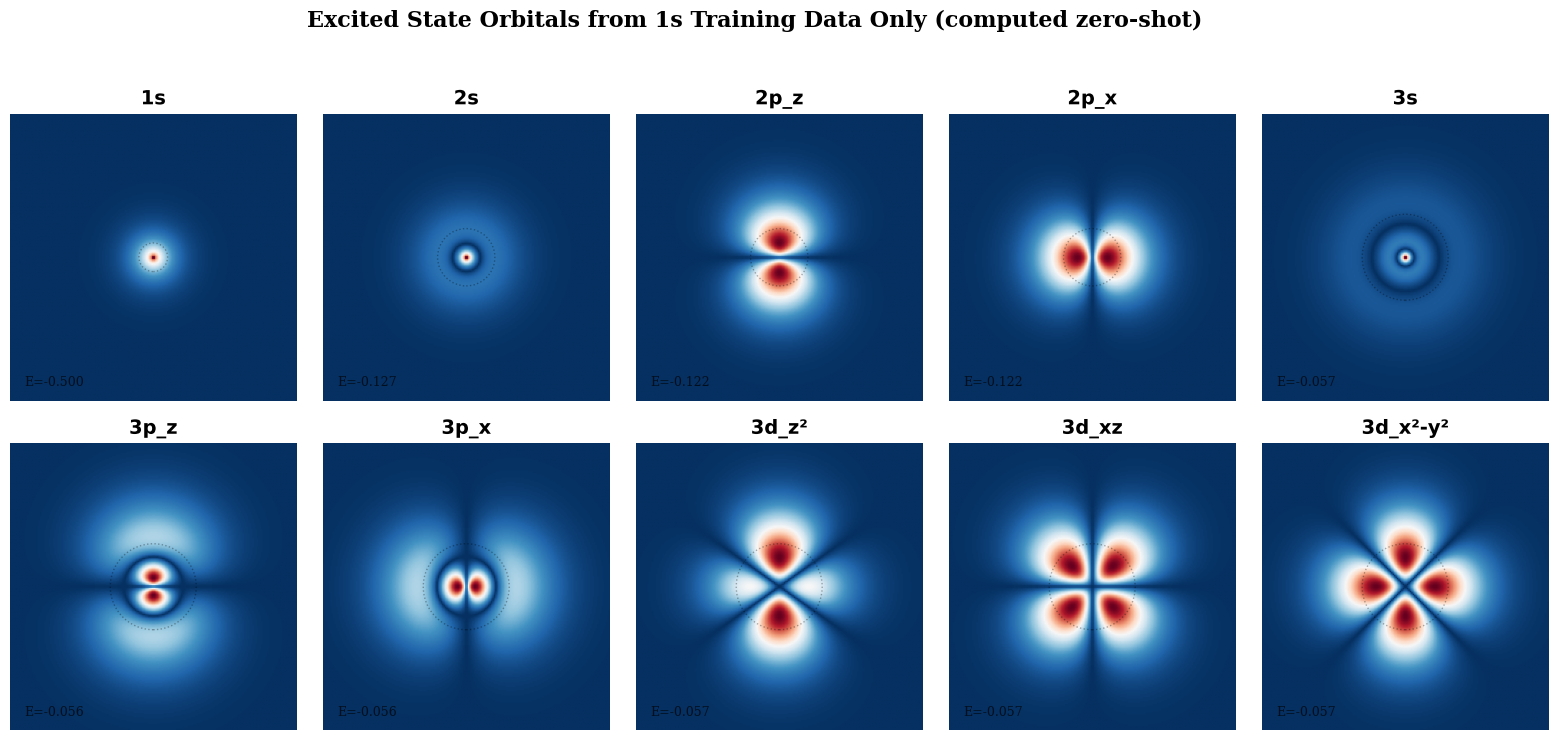

In [9]:
# ── Orbital visualisation ─────────────────────────────────────────────────────
# Reconstructs ψ_nlm(x) = R_nl(r)·Y_lm(θ,φ) from the radial wavefunctions
# recovered by the Schrödinger solver, then renders cross-section slices.

import matplotlib.patheffects as pe

orbitals = [
    (1, 0, '1s'),      (2, 0, '2s'),      (2, 1, '2p_z'),   (2, 1, '2p_x'),
    (3, 0, '3s'),      (3, 1, '3p_z'),    (3, 1, '3p_x'),
    (3, 2, '3d_z²'),   (3, 2, '3d_xz'),   (3, 2, '3d_x²-y²'),
]
zoom = {1: 10, 2: 20, 3: 30}

fig, axes = plt.subplots(2, 5, figsize=(20, 8), facecolor='white')
plt.subplots_adjust(wspace=0.05, hspace=0.15)

for ax, (n, l, label) in zip(axes.flatten(), orbitals):
    state = states.get((n, l)) or states.get((l + 1, l), {'u': np.zeros_like(r_grid), 'r': r_grid, 'E': 0.0})
    R_func = interp1d(state['r'], state['u'] / (state['r'] + 1e-9),
                      bounds_error=False, fill_value=0.0)

    box = zoom[n]
    lin = np.linspace(-box, box, 200)

    if 'z' in label:
        X, Z = np.meshgrid(lin, lin); Y = np.zeros_like(X)
    else:
        X, Y = np.meshgrid(lin, lin); Z = np.zeros_like(X)

    r3 = np.sqrt(X**2 + Y**2 + Z**2) + 1e-9
    xh, yh, zh = X / r3, Y / r3, Z / r3

    # Real spherical harmonics (unnormalized — for visualization only)
    if l == 0:
        Ang = 1.0
    elif l == 1:
        Ang = zh if 'z' in label else xh
    else:  # l == 2
        if 'z²'    in label: Ang = 3 * zh**2 - 1
        elif 'xz'  in label: Ang = xh * zh
        elif 'x²'  in label: Ang = xh**2 - yh**2
        else:                 Ang = 1.0

    Prob = (R_func(r3) * Ang)**2
    Prob = Prob / (Prob.max() + 1e-12)

    ax.imshow(np.sqrt(Prob), extent=[-box, box, -box, box],
              origin='lower', cmap='RdBu_r')
    title = ax.set_title(
        label,
        color='black',
        fontsize=14,
        fontweight='bold',
        pad=7,
        fontfamily='DejaVu Sans',
    )
    title.set_path_effects([pe.withStroke(linewidth=2.4, foreground='white', alpha=0.95)])
    ax.axis('off')
    ax.add_patch(patches.Circle((0, 0), n**2, edgecolor='black',
                                 facecolor='none', ls=':', alpha=0.30))
    if state['E'] != 0.0:
        ax.text(0.05, 0.05, f"E={state['E']:.3f}", transform=ax.transAxes,
                color='black', fontsize=9, alpha=0.70)

plt.suptitle("Excited State Orbitals from 1s Training Data Only (computed zero-shot)", color='black',
             fontsize=16, y=1.01, fontweight='bold')
plt.savefig("hydrogen_orbitals.pdf")
plt.show()